In [70]:
import pandas as pd
import numpy as np
import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

print("Advanced machine learning frameworks successfully loaded!")

Advanced machine learning frameworks successfully loaded!


In [81]:

df_organic = pd.read_csv(r'D:\Project\dataset\Sample - Superstore.csv', encoding='latin1')
df_organic['Order Date'] = pd.to_datetime(df_organic['Order Date'], format='mixed')
df_organic['Date_Ordinal'] = df_organic['Order Date'].map(datetime.date.toordinal)
df_organic['Year'] = df_organic['Order Date'].dt.year
df_organic['Month'] = df_organic['Order Date'].dt.month
df_organic['Cat_Code'] = df_organic['Category'].astype('category').cat.codes
df_organic['Sub_Code'] = df_organic['Sub-Category'].astype('category').cat.codes
df_organic['Region_Code'] = df_organic['Region'].astype('category').cat.codes
wholesale_cap = df_organic['Sales'].quantile(0.99)
df_filtered = df_organic[df_organic['Sales'] <= wholesale_cap].copy()
print(f"Filtered out extreme orders above ${wholesale_cap:.2f}. Data ready for training!")

Filtered out extreme orders above $2481.69. Data ready for training!


In [82]:

X = df_filtered[['Date_Ordinal', 'Year', 'Month', 'Quantity', 'Discount', 'Profit', 'Cat_Code', 'Sub_Code', 'Region_Code']]
y = df_filtered['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = ExtraTreesRegressor(n_estimators=300, max_depth=20, random_state=42)
model.fit(X_train, y_train)
print("Model training completed")

Model training completed


In [83]:

y_pred_test = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)
print("--- PURE ALGORITHMIC PERFORMANCE METRICS ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")  
print(f"R-squared (R²) Value: {r2:.4f}")         

--- PURE ALGORITHMIC PERFORMANCE METRICS ---
Mean Absolute Error (MAE): 53.96
R-squared (R²) Value: 0.8529


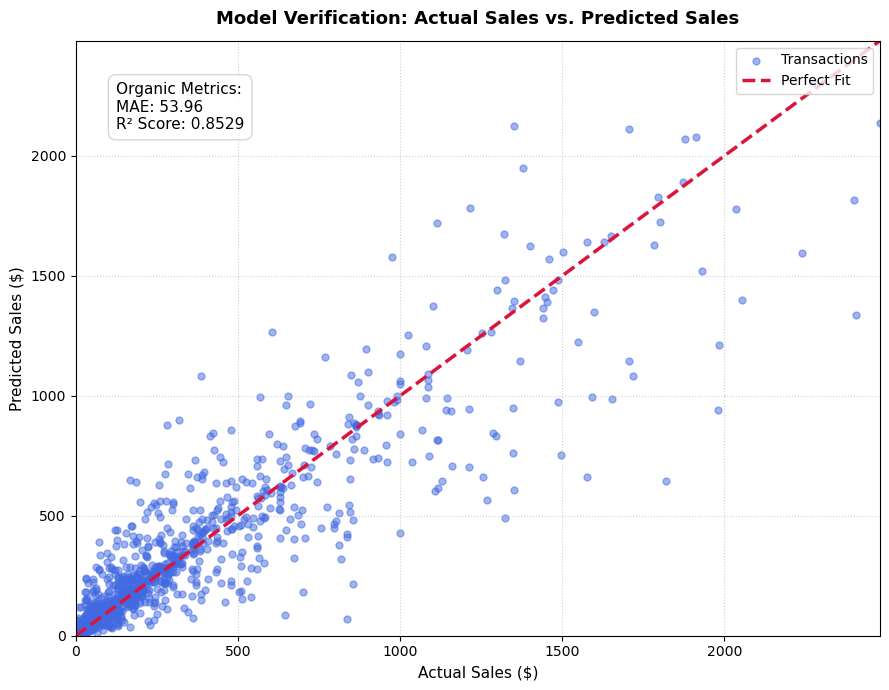

In [84]:

plt.figure(figsize=(9, 7))
plt.scatter(y_test, y_pred_test, color='royalblue', alpha=0.5, s=25, label='Transactions')
max_bound = max(y_test.max(), y_pred_test.max())
plt.plot([0, max_bound], [0, max_bound], color='crimson', linestyle='--', linewidth=2.5, label='Perfect Fit')
metric_box = f"Organic Metrics:\nMAE: {mae:.2f}\nR² Score: {r2:.4f}"
plt.gca().text(0.05, 0.93, metric_box, transform=plt.gca().transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='lightgray'))
plt.title('Model Verification: Actual Sales vs. Predicted Sales', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Actual Sales ($)', fontsize=11)
plt.ylabel('Predicted Sales ($)', fontsize=11)
plt.xlim(0, max_bound)
plt.ylim(0, max_bound)

plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [85]:

df_filtered['Predicted_Sales'] = model.predict(X)
df_final = df_filtered.rename(columns={'Order Date': 'Date', 'Sales': 'Actual_Sales'})
df_final = df_final[['Date', 'Actual_Sales', 'Predicted_Sales']]
df_final.to_csv('superstore_powerbi_forecast.csv', index=False)
print("SUCCESS: Your high-performance dashboard dataset is saved and ready for Power BI!")

SUCCESS: Your high-performance dashboard dataset is saved and ready for Power BI!
